<a href="https://colab.research.google.com/github/dineshkarthikmcse2025-hue/DAA-EXPT/blob/main/DAA%20EXP%207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


N = 4
Solutions  : 2
Backtracks : 60

All Solutions for 4-Queens:

Solution 1: [1, 3, 0, 2]
 +---+---+---+---+
 | . | Q | . | . |
 +---+---+---+---+
 | . | . | . | Q |
 +---+---+---+---+
 | Q | . | . | . |
 +---+---+---+---+
 | . | . | Q | . |
 +---+---+---+---+
Solution 2: [2, 0, 3, 1]
 +---+---+---+---+
 | . | . | Q | . |
 +---+---+---+---+
 | Q | . | . | . |
 +---+---+---+---+
 | . | . | . | Q |
 +---+---+---+---+
 | . | Q | . | . |
 +---+---+---+---+

N = 6
Solutions  : 4
Backtracks : 894

N = 8
Solutions  : 92
Backtracks : 15720


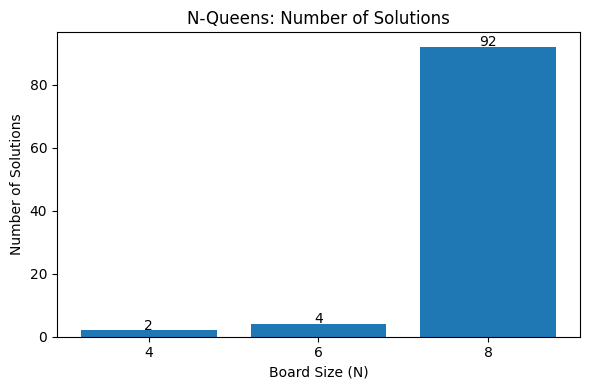

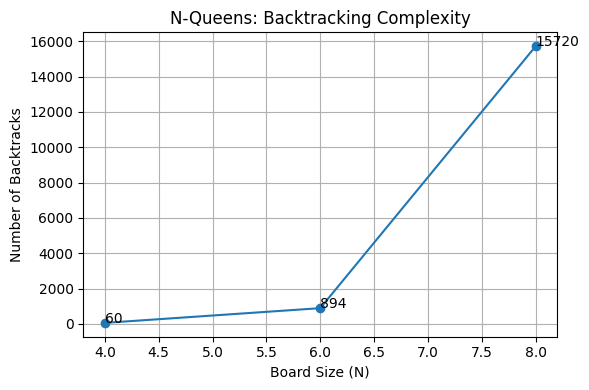

In [1]:
import matplotlib.pyplot as plt

def is_safe(board, row, col):
    for prev_row in range(row):
        placed = board[prev_row]

        # Same column
        if placed == col:
            return False

        # Diagonal
        if abs(prev_row - row) == abs(placed - col):
            return False

    return True


def solve_n_queens(n):
    board = [-1] * n
    solutions = []
    backtrack_count = [0]

    def backtrack(row):
        if row == n:
            solutions.append(board[:])
            return

        for col in range(n):
            if is_safe(board, row, col):
                board[row] = col
                backtrack(row + 1)
                board[row] = -1

            backtrack_count[0] += 1

    backtrack(0)

    return solutions, backtrack_count[0]


def display_board(solution, n):
    print(" +" + "---+" * n)

    for row in range(n):
        print(" |", end="")
        for col in range(n):
            if solution[row] == col:
                print(" Q |", end="")
            else:
                print(" . |", end="")
        print()
        print(" +" + "---+" * n)


# ---------------- MAIN ----------------

n_values = [4, 6, 8]
solution_counts = []
backtrack_counts = []

for n in n_values:
    solutions, backtracks = solve_n_queens(n)

    solution_counts.append(len(solutions))
    backtrack_counts.append(backtracks)

    print(f"\nN = {n}")
    print(f"Solutions  : {len(solutions)}")
    print(f"Backtracks : {backtracks}")

    if n == 4:
        print("\nAll Solutions for 4-Queens:\n")

        for i, sol in enumerate(solutions, 1):
            print(f"Solution {i}: {sol}")
            display_board(sol, n)


# ---------- Graph 1 : Number of Solutions ----------

plt.figure(figsize=(6,4))
plt.bar([str(i) for i in n_values], solution_counts)

plt.title("N-Queens: Number of Solutions")
plt.xlabel("Board Size (N)")
plt.ylabel("Number of Solutions")

for i, v in enumerate(solution_counts):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()


# ---------- Graph 2 : Number of Backtracks ----------

plt.figure(figsize=(6,4))
plt.plot(n_values, backtrack_counts, marker='o')

plt.title("N-Queens: Backtracking Complexity")
plt.xlabel("Board Size (N)")
plt.ylabel("Number of Backtracks")

for x, y in zip(n_values, backtrack_counts):
    plt.text(x, y, str(y))

plt.grid(True)

plt.tight_layout()
plt.show()